## Environment & Hardware Initialization

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image

In [2]:
# Set deterministic seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# Hardware acceleration setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Lifecycle Phase 1] Active execution device: {device}")

[Lifecycle Phase 1] Active execution device: cpu


## Data Audit & Quality Verification

In [4]:
data_dir = '../data/images'
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

print("[Lifecycle Phase 2] Running Data Integrity & Format Verification...")
total_images = 0
class_counts = {}

for root, dirs, files in os.walk(data_dir):
    folder_name = os.path.basename(root)
    if folder_name in ['healthy', 'cracked', 'hotspot', 'shadow']:
        valid_files = 0
        for f in files:
            if f.lower().endswith(valid_extensions):
                file_path = os.path.join(root, f)
                try:
                    # Verify image can be opened properly
                    with Image.open(file_path) as img:
                        img.verify()
                    valid_files += 1
                except Exception as e:
                    print(f"  [Warning] Corrupt file detected and skipped: {file_path} ({e})")
        class_counts[folder_name] = valid_files
        total_images += valid_files

print(f"Data Audit Complete. Total valid images found: {total_images}")
for cls, count in class_counts.items():
    print(f"  - Class '{cls}': {count} images")

[Lifecycle Phase 2] Running Data Integrity & Format Verification...
Data Audit Complete. Total valid images found: 605
  - Class 'cracked': 132 images
  - Class 'healthy': 75 images
  - Class 'hotspot': 357 images
  - Class 'shadow': 41 images


## Data Preprocessing, Augmentation & DataLoaders

In [5]:
# ImageNet Normalization constants
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# Training pipeline (Heavy Augmentation for Generalization)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Simulates environmental irradiance changes
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

# Validation pipeline (Strict resize & normalize without random noise)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

# Load entire dataset
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
class_names = full_dataset.classes

# Stratified 80% Train / 20% Validation Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Override validation set transform
val_dataset.dataset.transform = val_transform

# Create PyTorch DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"[Lifecycle Phase 3] Dataset split complete: {train_size} Training | {val_size} Validation")

[Lifecycle Phase 3] Dataset split complete: 484 Training | 121 Validation


## Class Imbalance Loss Weighting

In [6]:
# Compute loss weights dynamically based on actual class counts
counts = [class_counts[cls] for cls in class_names]
total_samples = sum(counts)
class_weights = [total_samples / max(1, count) for count in counts]

# Convert to PyTorch Tensor
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("[Lifecycle Phase 4] Class Loss Weights calculated:")
for cls, weight in zip(class_names, class_weights):
    print(f"  - Weight for '{cls}': {weight:.3f}")

[Lifecycle Phase 4] Class Loss Weights calculated:
  - Weight for 'cracked': 4.583
  - Weight for 'healthy': 8.067
  - Weight for 'hotspot': 1.695
  - Weight for 'shadow': 14.756


## Transfer Learning Model Architecture & Regularization

In [7]:
# Load Pretrained ResNet-18 Backbone
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify final FC layer for 4 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# Loss Function with Class Weighting
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# AdamW Optimizer + L2 Weight Decay Regularization
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)

# Learning Rate Scheduler (Reduces LR by half every 3 epochs)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

print("[Lifecycle Phase 5] ResNet-18 Architecture initialized with Weighted CrossEntropyLoss & AdamW.")

[Lifecycle Phase 5] ResNet-18 Architecture initialized with Weighted CrossEntropyLoss & AdamW.


## Model Training & Real-Time Validation Loop

In [8]:
epochs = 8
best_val_acc = 0.0
os.makedirs('../models', exist_ok=True)
best_model_path = '../models/resnet18_thermal_best.pth'

print("[Lifecycle Phase 6] Starting Fine-Tuning Execution...\n")

for epoch in range(epochs):
    # Training Mode
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        train_total += labels.size(0)
        
    scheduler.step()
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct.double() / train_total

    # Validation Mode
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            val_total += labels.size(0)
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct.double() / val_total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    # Checkpoint Best Performing Model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Best model updated and saved to '{best_model_path}'")

print("\nTraining completed successfully!")

[Lifecycle Phase 6] Starting Fine-Tuning Execution...

Epoch 1/8 | Train Loss: 0.2037 Acc: 93.80% | Val Loss: 0.0736 Acc: 99.17%
  --> Best model updated and saved to '../models/resnet18_thermal_best.pth'
Epoch 2/8 | Train Loss: 0.1116 Acc: 97.73% | Val Loss: 0.0763 Acc: 99.17%
Epoch 3/8 | Train Loss: 0.0672 Acc: 99.38% | Val Loss: 0.0637 Acc: 99.17%
Epoch 4/8 | Train Loss: 0.0714 Acc: 99.38% | Val Loss: 0.0881 Acc: 99.17%
Epoch 5/8 | Train Loss: 0.0459 Acc: 99.38% | Val Loss: 0.1140 Acc: 99.17%
Epoch 6/8 | Train Loss: 0.0423 Acc: 99.38% | Val Loss: 0.1236 Acc: 99.17%
Epoch 7/8 | Train Loss: 0.0399 Acc: 99.38% | Val Loss: 0.1251 Acc: 99.17%
Epoch 8/8 | Train Loss: 0.0369 Acc: 99.38% | Val Loss: 0.1377 Acc: 99.17%

Training completed successfully!


### Training time is 11 min 09 sec
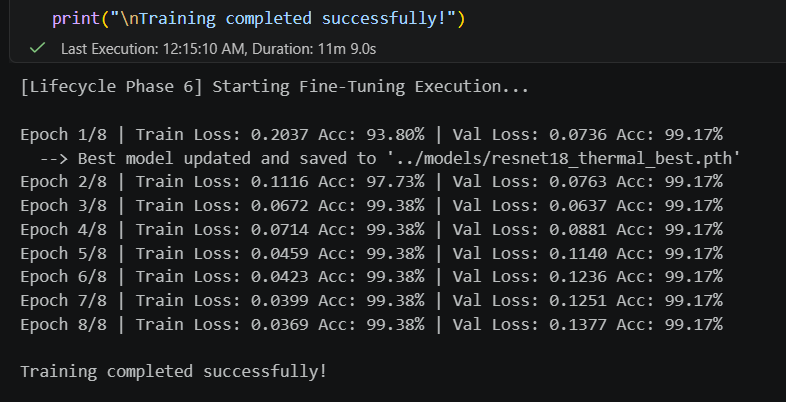

## Diagnostic Evaluation & Confusion Matrix

[Lifecycle Phase 7] Final Model Diagnostic Metrics:

              precision    recall  f1-score   support

     cracked       0.97      1.00      0.98        28
     healthy       1.00      0.94      0.97        17
     hotspot       1.00      1.00      1.00        68
      shadow       1.00      1.00      1.00         8

    accuracy                           0.99       121
   macro avg       0.99      0.99      0.99       121
weighted avg       0.99      0.99      0.99       121



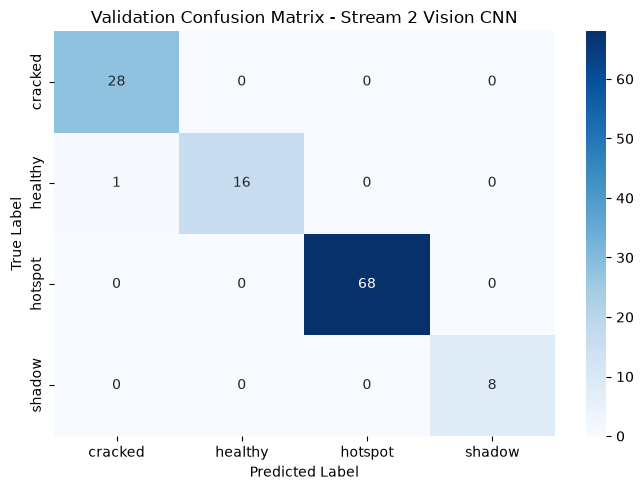

In [9]:
# Load Best Model Weights for Evaluation
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification Report
print("[Lifecycle Phase 7] Final Model Diagnostic Metrics:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix - Stream 2 Vision CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Explainable AI (Grad-CAM Visual Diagnostics)

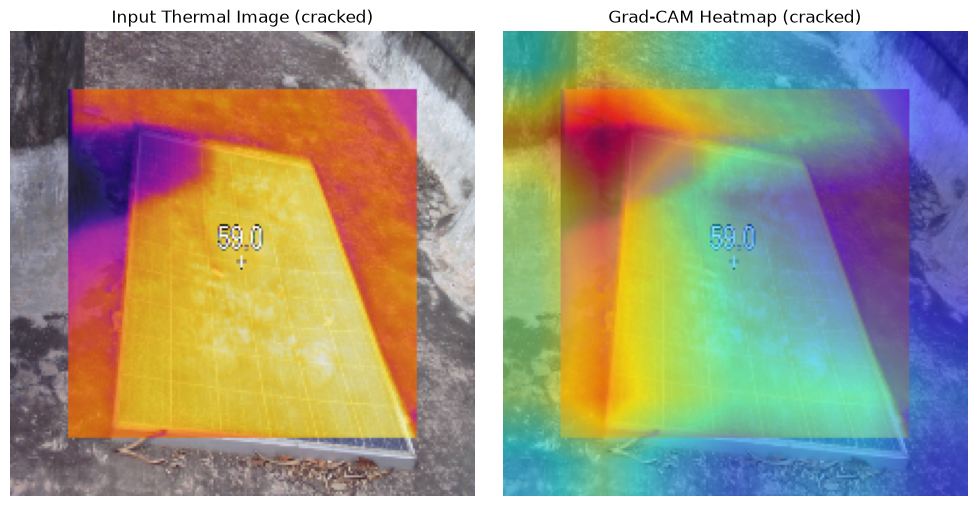

In [10]:
model.eval()
target_layers = [model.layer4[-1]]

# Grab a sample image from the validation set
sample_img_path = None
for root, _, files in os.walk(data_dir):
    for f in files:
        if f.lower().endswith(valid_extensions):
            sample_img_path = os.path.join(root, f)
            break
    if sample_img_path:
        break

# Image preprocessing for Grad-CAM
raw_img = cv2.imread(sample_img_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (224, 224))
rgb_img = np.float32(raw_img) / 255.0

# Prepare Tensor Input
input_tensor = val_transform(Image.fromarray(raw_img)).unsqueeze(0).to(device)

# 1. Infer model prediction class index
with torch.no_grad():
    output = model(input_tensor)
    pred_class_idx = torch.argmax(output, dim=1).item()
    pred_class_name = class_names[pred_class_idx]

# 2. Generate Grad-CAM Heatmap targeting predicted class
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(pred_class_idx)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 3. Display Explanation
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_img)
axes[0].set_title(f"Input Thermal Image ({pred_class_name})")
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title(f"Grad-CAM Heatmap ({pred_class_name})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Model Artifact Persistence

In [11]:
final_path = '../models/resnet18_thermal.pth'
torch.save(model.state_dict(), final_path)
print(f"[Lifecycle Phase 9] Stream 2 Vision model saved at '{final_path}'.")

[Lifecycle Phase 9] Stream 2 Vision model saved at '../models/resnet18_thermal.pth'.
